# Exploratory Data Analysis of Unemployment Data in Indonesia

**Dataset:** Tingkat Pengangguran Terbuka (TPT) berdasarkan tingkat pendidikan  
**Periode:** Agustus 2022–2024  
**Sumber:** Badan Pusat Statistik (BPS) **bold text**

In [8]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print("pandas:", pd.__version__)

pandas: 2.2.3


## 1. Memuat Dataset

Dataset yang digunakan berisi data Tingkat Pengangguran Terbuka (TPT)
di Indonesia berdasarkan tingkat pendidikan pada periode Agustus
2022–2024.

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import os

matches = []

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if 'Dataset_Acuan.xlsx' in files:
        matches.append(os.path.join(root, 'Dataset_Acuan.xlsx'))

matches

['/content/drive/MyDrive/Semester 3/Exploratory Data Analysis/P03/Data/Dataset_Acuan.xlsx']

**Membaca Dataset**

In [11]:
file_path = matches[0]

df = pd.read_excel('/content/drive/MyDrive/Semester 3/Exploratory Data Analysis/P03/Data/Dataset_Acuan.xlsx')

df

,tahun,periode,tingkat_pendidikan,TPT
0,2022,Agustus,SD ke bawah,1.47
1,2022,Agustus,SMP,3.23
2,2022,Agustus,SMA,10.49
3,2022,Agustus,SMK,13.09
4,2022,Agustus,Diploma I/II/III,15.14
5,2022,Agustus,Diploma IV/S1/S2/S3,7.39
6,2023,Agustus,SD ke bawah,1.92
7,2023,Agustus,SMP,2.91
8,2023,Agustus,SMA,9.28
9,2023,Agustus,SMK,9.82


**Cek struktur dataset**

In [12]:
# Melihat informasi dasar dataset
print("Ukuran dataset:", df.shape)
print("\nNama kolom dan tipe data:")
print(df.dtypes)

Ukuran dataset: (18, 4)

Nama kolom dan tipe data:
tahun                   int64
periode                object
tingkat_pendidikan     object
TPT                   float64
dtype: object


**Cek data kosong & duplikat**

In [13]:
print("Jumlah nilai kosong tiap kolom:")
print(df.isna().sum())

print("\nJumlah data duplikat:")
print(df.duplicated().sum())

Jumlah nilai kosong tiap kolom:
tahun                 0
periode               0
tingkat_pendidikan    0
TPT                   0
dtype: int64

Jumlah data duplikat:
0


**cek isi/kategori setiap kolom.**

In [14]:
print("Tahun:")
print(df["tahun"].unique())

print("\nPeriode:")
print(df["periode"].unique())

print("\nTingkat pendidikan:")
print(df["tingkat_pendidikan"].unique())

print("\nRentang TPT:")
print("Minimum:", df["TPT"].min())
print("Maksimum:", df["TPT"].max())

Tahun:
[2022 2023 2024]

Periode:
['Agustus']

Tingkat pendidikan:
['SD ke bawah' 'SMP' 'SMA' 'SMK' 'Diploma I/II/III' 'Diploma IV/S1/S2/S3']

Rentang TPT:
Minimum: 1.47
Maksimum: 15.14


**Statistik TPT**

In [15]:
print("Statistik deskriptif TPT:")
print(df["TPT"].describe())

Statistik deskriptif TPT:
count    18.000000
mean      7.182778
std       3.895549
min       1.470000
25%       3.510000
50%       7.425000
75%       9.422500
max      15.140000
Name: TPT, dtype: float64


**Tabel TPT per tahun & pendidikan**

In [17]:
tabel_tpt = df.pivot(
    index="tingkat_pendidikan",
    columns="tahun",
    values="TPT"
)

print("Tabel TPT berdasarkan tingkat pendidikan dan tahun:")
tabel_tpt

Tabel TPT berdasarkan tingkat pendidikan dan tahun:


tahun,2022,2023,2024
tingkat_pendidikan,,,
Diploma I/II/III,15.14,9.47,5.46
Diploma IV/S1/S2/S3,7.39,9.09,7.09
SD ke bawah,1.47,1.92,2.69
SMA,10.49,9.28,8.94
SMK,13.09,9.82,7.46
SMP,3.23,2.91,4.35


## 4. Analisis Data

Pertanyaan analisis yang digunakan:

1. Bagaimana pola Tingkat Pengangguran Terbuka (TPT) di Indonesia
   berdasarkan tingkat pendidikan dan periode pengamatan?

2. Tingkat pendidikan mana yang memiliki TPT paling tinggi dan paling
   rendah pada setiap periode pengamatan?

3. Bagaimana perubahan TPT pada setiap tingkat pendidikan dari satu
   periode pengamatan ke periode berikutnya?

4. Bagaimana perbedaan rata-rata TPT antar tingkat pendidikan selama
   periode pengamatan?

5. Apakah selisih TPT antara tingkat pendidikan dengan TPT tertinggi
   dan terendah semakin besar atau semakin kecil dari waktu ke waktu?

**Visualisasi TPT**

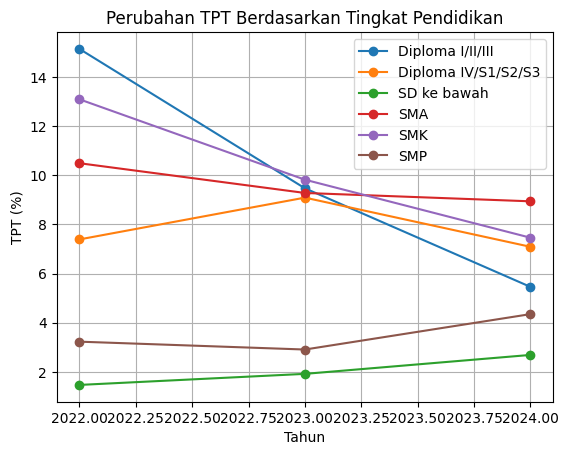

In [19]:
#Bagaimana pola Tingkat Pengangguran Terbuka (TPT) di Indonesia berdasarkan tingkat pendidikan dan periode pengamatan?
import matplotlib.pyplot as plt

for pendidikan in tabel_tpt.index:
    plt.plot(
        tabel_tpt.columns,
        tabel_tpt.loc[pendidikan],
        marker="o",
        label=pendidikan
    )

plt.title("Perubahan TPT Berdasarkan Tingkat Pendidikan")
plt.xlabel("Tahun")
plt.ylabel("TPT (%)")
plt.legend()
plt.grid(True)
plt.show()

**TPT tertinggi & terendah**

In [20]:
#Tingkat pendidikan mana yang memiliki TPT paling tinggi dan paling rendah pada setiap periode pengamatan?
for tahun in sorted(df["tahun"].unique()):
    data_tahun = df[df["tahun"] == tahun]

    tertinggi = data_tahun.loc[data_tahun["TPT"].idxmax()]
    terendah = data_tahun.loc[data_tahun["TPT"].idxmin()]

    print(f"\nTahun {tahun}:")
    print(
        f"TPT tertinggi  : {tertinggi['tingkat_pendidikan']} = {tertinggi['TPT']:.2f}%"
    )
    print(
        f"TPT terendah   : {terendah['tingkat_pendidikan']} = {terendah['TPT']:.2f}%"
    )


Tahun 2022:
TPT tertinggi  : Diploma I/II/III = 15.14%
TPT terendah   : SD ke bawah = 1.47%

Tahun 2023:
TPT tertinggi  : SMK = 9.82%
TPT terendah   : SD ke bawah = 1.92%

Tahun 2024:
TPT tertinggi  : SMA = 8.94%
TPT terendah   : SD ke bawah = 2.69%


**Menghitung perubahan TPT**

In [21]:
#Bagaimana perubahan TPT pada setiap tingkat pendidikan dari satu periode pengamatan ke periode berikutnya?
perubahan_tpt = tabel_tpt.diff(axis=1)

print("Perubahan TPT dari tahun sebelumnya:")
perubahan_tpt

Perubahan TPT dari tahun sebelumnya:


tahun,2022,2023,2024
tingkat_pendidikan,,,
Diploma I/II/III,NaN,-5.67,-4.01
Diploma IV/S1/S2/S3,NaN,1.70,-2.00
SD ke bawah,NaN,0.45,0.77
SMA,NaN,-1.21,-0.34
SMK,NaN,-3.27,-2.36
SMP,NaN,-0.32,1.44


**Menghitung rata-rata TPT berdasarkan tingkat pendidikan**

In [22]:
#Bagaimana perbedaan rata-rata TPT antar tingkat pendidikan selama periode pengamatan?
rata_tpt_pendidikan = df.groupby("tingkat_pendidikan")["TPT"].mean().sort_values(ascending=False)

print("Rata-rata TPT berdasarkan tingkat pendidikan:")
print(rata_tpt_pendidikan)

Rata-rata TPT berdasarkan tingkat pendidikan:
tingkat_pendidikan
SMK                    10.123333
Diploma I/II/III       10.023333
SMA                     9.570000
Diploma IV/S1/S2/S3     7.856667
SMP                     3.496667
SD ke bawah             2.026667
Name: TPT, dtype: float64


**Menghitung selisih TPT tertinggi dan terendah setiap tahun**

In [23]:
#Apakah selisih TPT antara tingkat pendidikan dengan TPT tertinggi dan terendah semakin besar atau semakin kecil dari waktu ke waktu?
selisih_tpt = df.groupby("tahun")["TPT"].agg(["max", "min"])

selisih_tpt["selisih"] = selisih_tpt["max"] - selisih_tpt["min"]

print("Selisih TPT tertinggi dan terendah setiap tahun:")
print(selisih_tpt)

Selisih TPT tertinggi dan terendah setiap tahun:
         max   min  selisih
tahun                      
2022   15.14  1.47    13.67
2023    9.82  1.92     7.90
2024    8.94  2.69     6.25


**Ringkasan Hasil Analisis Tingkat Pengangguran Terbuka (TPT) berdasarkan tingkat pendidikan di Indonesia**

In [24]:
print("RINGKASAN HASIL ANALISIS EDA")
print("=" * 50)

print("\n1. Pola TPT berdasarkan tingkat pendidikan:")
print("TPT menunjukkan pola yang berbeda pada setiap tingkat pendidikan.")
print("Beberapa kategori mengalami penurunan, sementara kategori lainnya mengalami kenaikan.")

print("\n2. TPT tertinggi dan terendah setiap tahun:")
print("2022 → Tertinggi: Diploma I/II/III (15.14%), Terendah: SD ke bawah (1.47%)")
print("2023 → Tertinggi: SMK (9.82%), Terendah: SD ke bawah (1.92%)")
print("2024 → Tertinggi: SMA (8.94%), Terendah: SD ke bawah (2.69%)")

print("\n3. Perubahan TPT dari tahun ke tahun:")
print("Diploma I/II/III, SMA, dan SMK mengalami penurunan TPT.")
print("SD ke bawah mengalami kenaikan TPT pada setiap periode.")
print("Diploma IV/S1/S2/S3 dan SMP mengalami perubahan yang naik-turun.")

print("\n4. Rata-rata TPT berdasarkan tingkat pendidikan:")
print("Rata-rata TPT tertinggi: SMK (10.12%)")
print("Rata-rata TPT terendah: SD ke bawah (2.03%)")

print("\n5. Perbedaan TPT tertinggi dan terendah:")
print("2022 → 13.67 poin")
print("2023 → 7.90 poin")
print("2024 → 6.25 poin")
print("Selisih TPT semakin kecil dari tahun ke tahun.")

RINGKASAN HASIL ANALISIS EDA

1. Pola TPT berdasarkan tingkat pendidikan:
TPT menunjukkan pola yang berbeda pada setiap tingkat pendidikan.
Beberapa kategori mengalami penurunan, sementara kategori lainnya mengalami kenaikan.

2. TPT tertinggi dan terendah setiap tahun:
2022 → Tertinggi: Diploma I/II/III (15.14%), Terendah: SD ke bawah (1.47%)
2023 → Tertinggi: SMK (9.82%), Terendah: SD ke bawah (1.92%)
2024 → Tertinggi: SMA (8.94%), Terendah: SD ke bawah (2.69%)

3. Perubahan TPT dari tahun ke tahun:
Diploma I/II/III, SMA, dan SMK mengalami penurunan TPT.
SD ke bawah mengalami kenaikan TPT pada setiap periode.
Diploma IV/S1/S2/S3 dan SMP mengalami perubahan yang naik-turun.

4. Rata-rata TPT berdasarkan tingkat pendidikan:
Rata-rata TPT tertinggi: SMK (10.12%)
Rata-rata TPT terendah: SD ke bawah (2.03%)

5. Perbedaan TPT tertinggi dan terendah:
2022 → 13.67 poin
2023 → 7.90 poin
2024 → 6.25 poin
Selisih TPT semakin kecil dari tahun ke tahun.


**Kesimpulan Analisis**

In [25]:
print("KESIMPULAN ANALISIS EDA")
print("=" * 50)

print("""
Berdasarkan hasil Exploratory Data Analysis (EDA) terhadap data TPT
di Indonesia berdasarkan tingkat pendidikan pada periode Agustus
2022–2024, terlihat bahwa pola TPT berbeda pada setiap tingkat
pendidikan.

TPT tertinggi berubah setiap tahun, yaitu Diploma I/II/III pada tahun
2022, SMK pada tahun 2023, dan SMA pada tahun 2024. Sementara itu,
SD ke bawah selalu memiliki TPT terendah pada ketiga tahun pengamatan.

Dari rata-rata selama periode pengamatan, SMK memiliki TPT tertinggi
sebesar 10,12%, sedangkan SD ke bawah memiliki rata-rata TPT terendah
sebesar 2,03%.

Selain itu, selisih antara TPT tertinggi dan terendah mengalami
penurunan dari 13,67 poin pada 2022 menjadi 7,90 poin pada 2023 dan
6,25 poin pada 2024. Hal ini menunjukkan bahwa perbedaan TPT antar
tingkat pendidikan semakin menyempit selama periode pengamatan.
""")

KESIMPULAN ANALISIS EDA

Berdasarkan hasil Exploratory Data Analysis (EDA) terhadap data TPT
di Indonesia berdasarkan tingkat pendidikan pada periode Agustus
2022–2024, terlihat bahwa pola TPT berbeda pada setiap tingkat
pendidikan.

TPT tertinggi berubah setiap tahun, yaitu Diploma I/II/III pada tahun
2022, SMK pada tahun 2023, dan SMA pada tahun 2024. Sementara itu,
SD ke bawah selalu memiliki TPT terendah pada ketiga tahun pengamatan.

Dari rata-rata selama periode pengamatan, SMK memiliki TPT tertinggi
sebesar 10,12%, sedangkan SD ke bawah memiliki rata-rata TPT terendah
sebesar 2,03%.

Selain itu, selisih antara TPT tertinggi dan terendah mengalami
penurunan dari 13,67 poin pada 2022 menjadi 7,90 poin pada 2023 dan
6,25 poin pada 2024. Hal ini menunjukkan bahwa perbedaan TPT antar
tingkat pendidikan semakin menyempit selama periode pengamatan.

